# Dust Emission Model Gallery

tengri implements **10 dust emission models** spanning simple analytic
modified blackbodies through physically-motivated template libraries.
All models are pure JAX (JIT-compatible, fully differentiable) and
enforce energy balance: total IR luminosity = total absorbed luminosity.

This notebook showcases every model, compares their SEDs, and
demonstrates the effect of each parameter.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Template file.*not found.*")
warnings.filterwarnings("ignore", message=".*DL07 template.*not found.*")
warnings.filterwarnings("ignore", message=".*Failed to load.*")

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join("models", "figures")
os.makedirs(FIGDIR, exist_ok=True)

In [2]:
from tengri.models.dust.emission import (
    DUST_EMISSION_MODELS,
    _draine_li2007_analytic_fallback,
    _draine_li2014_analytic_fallback,
    _dale2014_analytic_fallback,
    _astrodust_analytic_fallback,
    _bosa_analytic_fallback,
    _themis_analytic_fallback,
    _pah_template,
    _PAH_CENTER_UM,
    _drude_profile,
    _PAH_FWHM_UM,
    _PAH_STRENGTH,
    _modified_blackbody_component,
    cmb_corrected_temperature,
    cmb_contrast_factor,
    energy_balance_split,
    get_emission_model,
    magphys_dc08,
    modified_blackbody,
    casey2012,
    planck_bnu,
)

## Shared Setup

All models are evaluated on a common rest-frame wavelength grid from
1 to 1000 um (10000 to 10000000 Angstrom) with logarithmic spacing.

In [3]:
# Wavelength grid: 1--1000 um in Angstrom
wave_aa = jnp.logspace(np.log10(1e4), np.log10(1e7), 2000)
wave_um = wave_aa * 1e-4  # for plotting in microns

# Common parameters
L_ABS = 1e10  # Lsun — total absorbed luminosity

# Color palette for model comparison
MODEL_COLORS = {
    "modified_blackbody": "#1f77b4",
    "casey2012": "#ff7f0e",
    "magphys": "#2ca02c",
    "draine_li2007": "#d62728",
    "draine_li2014": "#9467bd",
    "dale2014": "#8c564b",
    "astrodust": "#e377c2",
    "bosa": "#17becf",
    "themis": "#bcbd22",
    "energy_balance_split": "#7f7f7f",
}

# Consistent line styling
MODEL_LABELS = {
    "modified_blackbody": "Modified BB",
    "casey2012": "Casey (2012)",
    "magphys": "MAGPHYS (dC+08)",
    "draine_li2007": "DL07",
    "draine_li2014": "DL14",
    "dale2014": "Dale+2014",
    "astrodust": "Astrodust+PAH",
    "bosa": "BOSA (B&S21)",
    "themis": "THEMIS (J+17)",
    "energy_balance_split": "Energy Balance Split",
}


def _set_reasonable_log_ylim(ax, pad_log=0.12):
    """Tighten log-scale *y* limits from line data within the axis *x* range."""
    x_lo, x_hi = ax.get_xlim()
    ys = []
    for line in ax.get_lines():
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())
        m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y) & (y > 0)
        if np.any(m):
            ys.append(y[m])
    if not ys:
        return
    y = np.concatenate(ys)
    lo, hi = float(np.min(y)), float(np.max(y))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo <= 0 or hi <= 0:
        return
    if hi / lo < 1.02:
        lo, hi = lo * 0.7, hi * 1.4
    ax.set_ylim(10 ** (np.log10(lo) - pad_log), 10 ** (np.log10(hi) + pad_log))

---
## 1. Overview -- All Models at T=35 K

A single plot comparing every emission model at `L_absorbed = 1e10 Lsun`
and T=35 K (where applicable). Template-based models use their
analytic fallbacks here for guaranteed availability.

W0405 03:44:06.644182 36369444 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


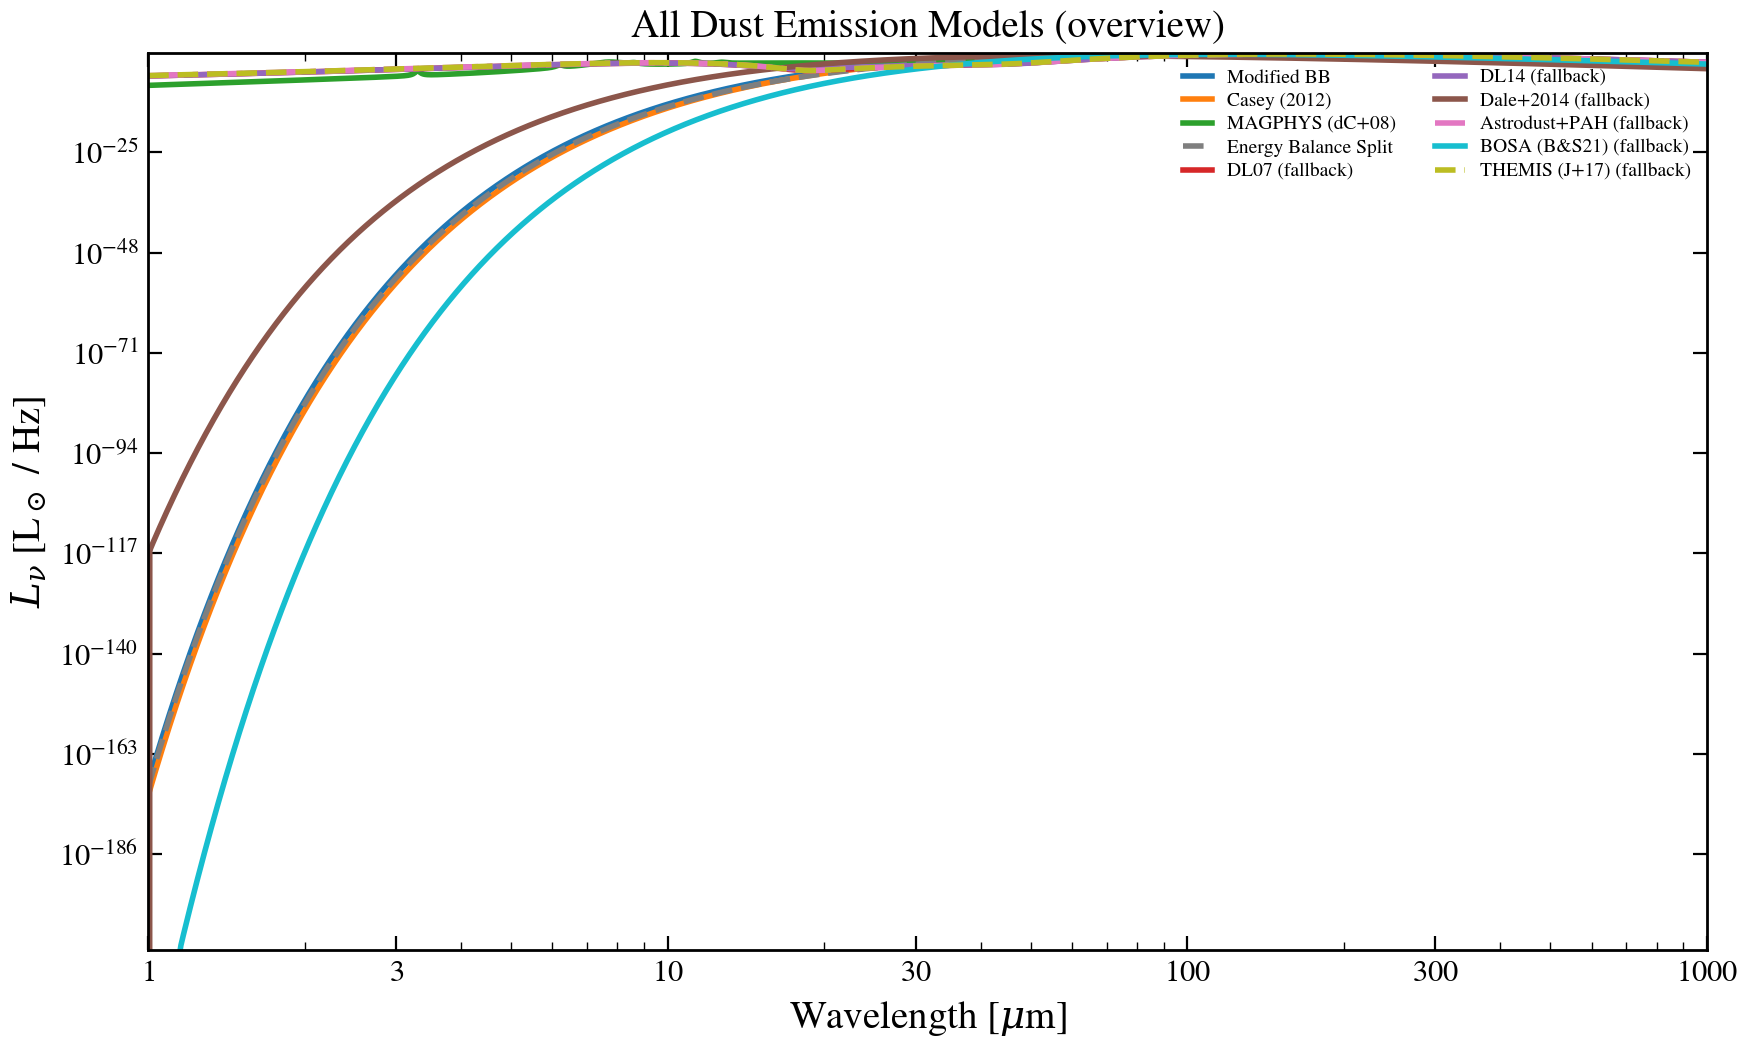

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- Analytic models ---
# Modified blackbody
lnu_mbb = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8)
ax.plot(
    wave_um,
    np.array(lnu_mbb),
    color=MODEL_COLORS["modified_blackbody"],
    lw=2.0,
    label=MODEL_LABELS["modified_blackbody"],
)

# Casey 2012
lnu_casey = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=2.0)
ax.plot(
    wave_um,
    np.array(lnu_casey),
    color=MODEL_COLORS["casey2012"],
    lw=2.0,
    label=MODEL_LABELS["casey2012"],
)

# MAGPHYS (uses its own temperature parameterization, set warm~35 K)
lnu_magphys = magphys_dc08(
    wave_aa,
    L_ABS,
    dust_T_warm=35.0,
    dust_T_cold=20.0,
    dust_T_hot=180.0,
    dust_xi_pah=0.06,
    dust_xi_mir=0.07,
    dust_xi_warm=0.25,
)
ax.plot(
    wave_um,
    np.array(lnu_magphys),
    color=MODEL_COLORS["magphys"],
    lw=2.0,
    label=MODEL_LABELS["magphys"],
)

# Energy balance split
lnu_ebs = energy_balance_split(wave_aa, L_ABS, dust_T_warm=35.0, dust_T_cold=20.0)
ax.plot(
    wave_um,
    np.array(lnu_ebs),
    color=MODEL_COLORS["energy_balance_split"],
    lw=2.0,
    ls="--",
    label=MODEL_LABELS["energy_balance_split"],
)

# --- Template-based models (analytic fallbacks for guaranteed availability) ---
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
ax.plot(
    wave_um,
    np.array(lnu_dl07),
    color=MODEL_COLORS["draine_li2007"],
    lw=2.0,
    label=f"{MODEL_LABELS['draine_li2007']} (fallback)",
)

lnu_dl14 = _draine_li2014_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5, dust_alpha_dl14=2.0
)
ax.plot(
    wave_um,
    np.array(lnu_dl14),
    color=MODEL_COLORS["draine_li2014"],
    lw=2.0,
    label=f"{MODEL_LABELS['draine_li2014']} (fallback)",
)

lnu_dale = _dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=2.0)
ax.plot(
    wave_um,
    np.array(lnu_dale),
    color=MODEL_COLORS["dale2014"],
    lw=2.0,
    label=f"{MODEL_LABELS['dale2014']} (fallback)",
)

lnu_astro = _astrodust_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=3.0
)
ax.plot(
    wave_um,
    np.array(lnu_astro),
    color=MODEL_COLORS["astrodust"],
    lw=2.0,
    ls="-.",
    label=f"{MODEL_LABELS['astrodust']} (fallback)",
)

lnu_bosa = _bosa_analytic_fallback(wave_aa, L_ABS, dust_log_ssfr=-10.0)
ax.plot(
    wave_um,
    np.array(lnu_bosa),
    color=MODEL_COLORS["bosa"],
    lw=2.0,
    label=f"{MODEL_LABELS['bosa']} (fallback)",
)

lnu_themis = _themis_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=0.17
)
ax.plot(
    wave_um,
    np.array(lnu_themis),
    color=MODEL_COLORS["themis"],
    lw=2.0,
    ls="--",
    label=f"{MODEL_LABELS['themis']} (fallback)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("All Dust Emission Models (overview)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xticks([1, 3, 10, 30, 100, 300, 1000])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_overview_all_models.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Analytic Models

### 2a. Modified Blackbody

The simplest dust emission model: $S_\nu \propto \nu^\beta B_\nu(T)$.
Two free parameters: temperature $T$ and emissivity index $\beta$.

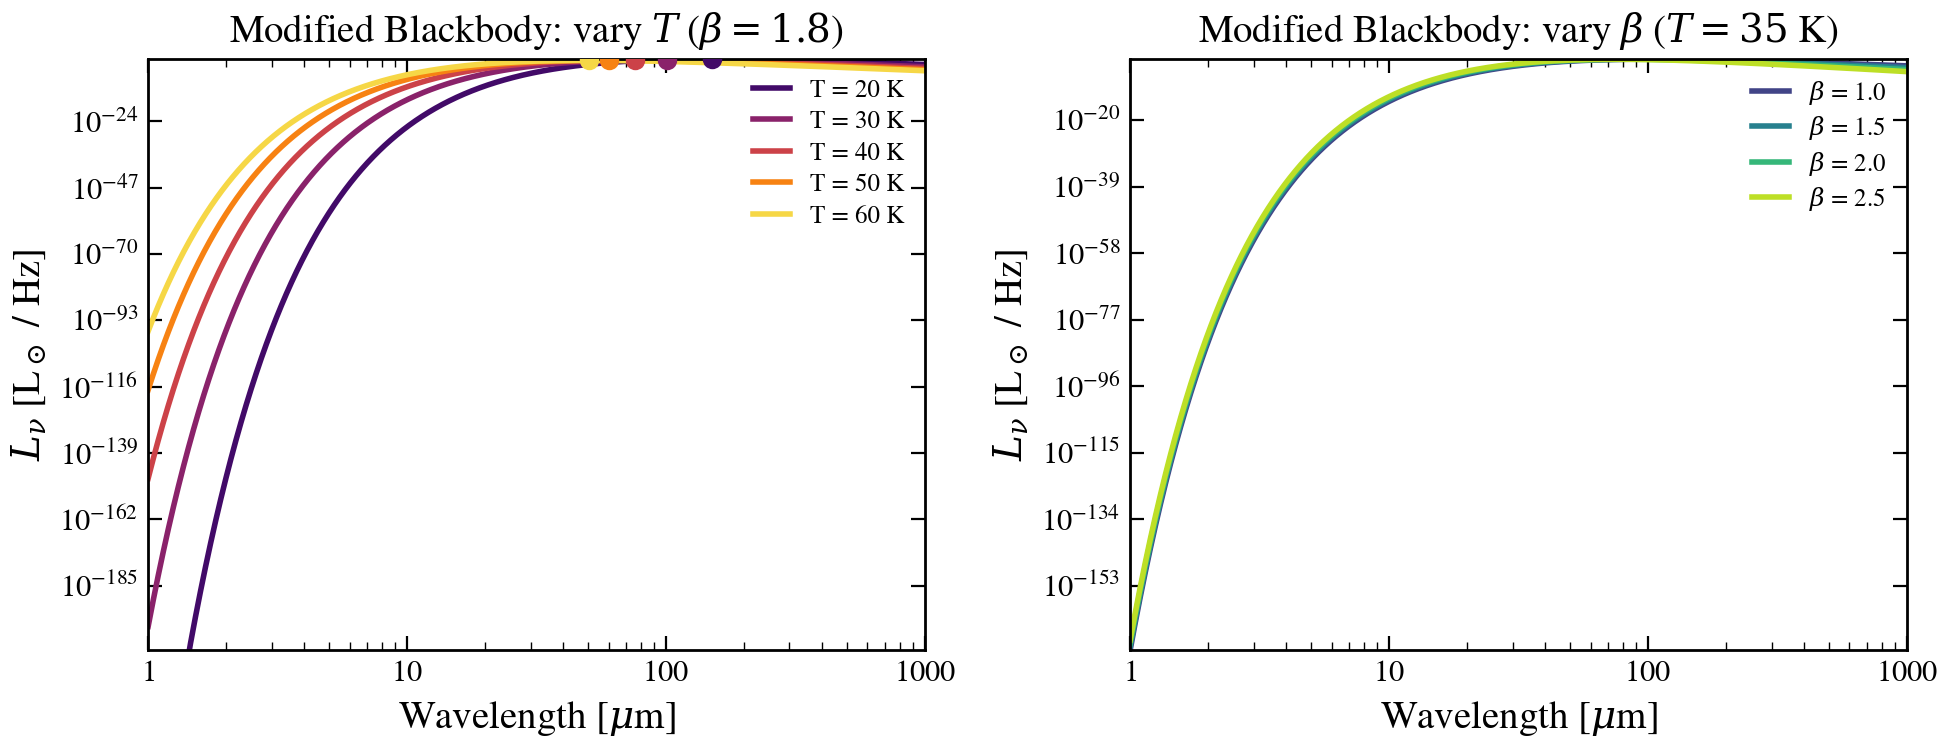

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Vary temperature ---
ax = axes[0]
temps = [20, 30, 40, 50, 60]
cmap = plt.cm.inferno
for i, T in enumerate(temps):
    lnu = modified_blackbody(wave_aa, L_ABS, dust_T=float(T), dust_beta_ir=1.8)
    color = cmap(0.2 + 0.7 * i / (len(temps) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"T = {T} K")

    # Mark Wien peak: lambda_peak ~ 2898 / T um (Wien's law, approximate for MBB)
    # Actual peak of nu^beta * B_nu shifts from the simple Wien peak
    peak_idx = int(np.argmax(np.array(lnu)))
    ax.plot(wave_um[peak_idx], np.array(lnu)[peak_idx], "o", color=color, ms=6, zorder=5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Modified Blackbody: vary $T$ ($\beta = 1.8$)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary beta ---
ax = axes[1]
betas = [1.0, 1.5, 2.0, 2.5]
cmap = plt.cm.viridis
for i, beta in enumerate(betas):
    lnu = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=beta)
    color = cmap(0.2 + 0.7 * i / (len(betas) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\beta$ = {beta:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Modified Blackbody: vary $\beta$ ($T = 35$ K)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_modified_blackbody.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2b. Casey (2012)

Extends the modified blackbody with a mid-IR power-law component
to capture the 8--40 um excess from warm dust continuum emission.
The two components are joined by a smooth sigmoid transition function.

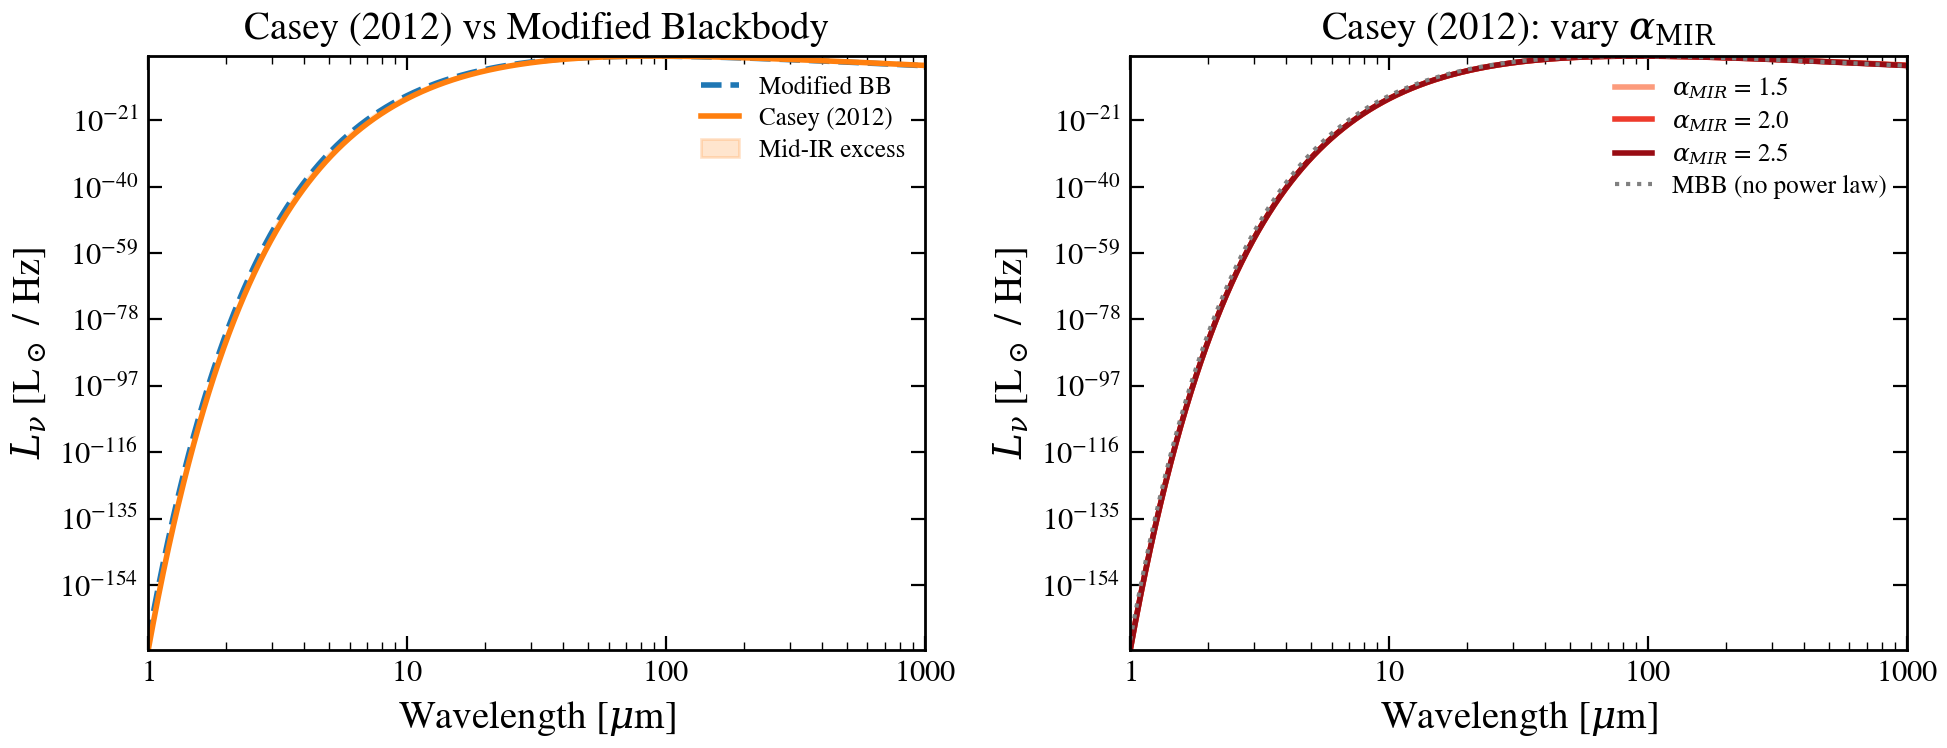

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Casey vs MBB comparison ---
ax = axes[0]
lnu_mbb = modified_blackbody(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8)
lnu_c12 = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=2.0)

ax.plot(
    wave_um,
    np.array(lnu_mbb),
    lw=2.0,
    ls="--",
    color=MODEL_COLORS["modified_blackbody"],
    label="Modified BB",
)
ax.plot(wave_um, np.array(lnu_c12), lw=2.0, color=MODEL_COLORS["casey2012"], label="Casey (2012)")

# Shade the mid-IR excess region
lnu_mbb_arr = np.array(lnu_mbb)
lnu_c12_arr = np.array(lnu_c12)
wave_um_arr = np.array(wave_um)
mask_excess = (wave_um_arr >= 3) & (wave_um_arr <= 60)
ax.fill_between(
    wave_um_arr[mask_excess],
    lnu_mbb_arr[mask_excess],
    lnu_c12_arr[mask_excess],
    alpha=0.2,
    color=MODEL_COLORS["casey2012"],
    label="Mid-IR excess",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Casey (2012) vs Modified Blackbody")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary alpha_mir ---
ax = axes[1]
alphas = [1.5, 2.0, 2.5]
cmap = plt.cm.Reds
for i, alpha in enumerate(alphas):
    lnu = casey2012(wave_aa, L_ABS, dust_T=35.0, dust_beta_ir=1.8, dust_alpha_mir=alpha)
    color = cmap(0.35 + 0.55 * i / (len(alphas) - 1))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\alpha_{{MIR}}$ = {alpha:.1f}")

# Reference MBB
ax.plot(wave_um, np.array(lnu_mbb), lw=1.5, ls=":", color="grey", label="MBB (no power law)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Casey (2012): vary $\alpha_{\mathrm{MIR}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_casey2012.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2c. MAGPHYS 4-Component Model (da Cunha, Charlot & Elbaz 2008)

Decomposes dust emission into four physically-motivated components:
1. **PAH features** -- Drude profiles at 3.3, 6.2, 7.7, 8.6, 11.3, 12.7 um
2. **Hot MIR continuum** -- Very small grains near young stars (T ~ 180 K)
3. **Warm birth-cloud grains** -- BC component (T ~ 45 K)
4. **Cold ISM grains** -- Diffuse ISM component (T ~ 20 K)

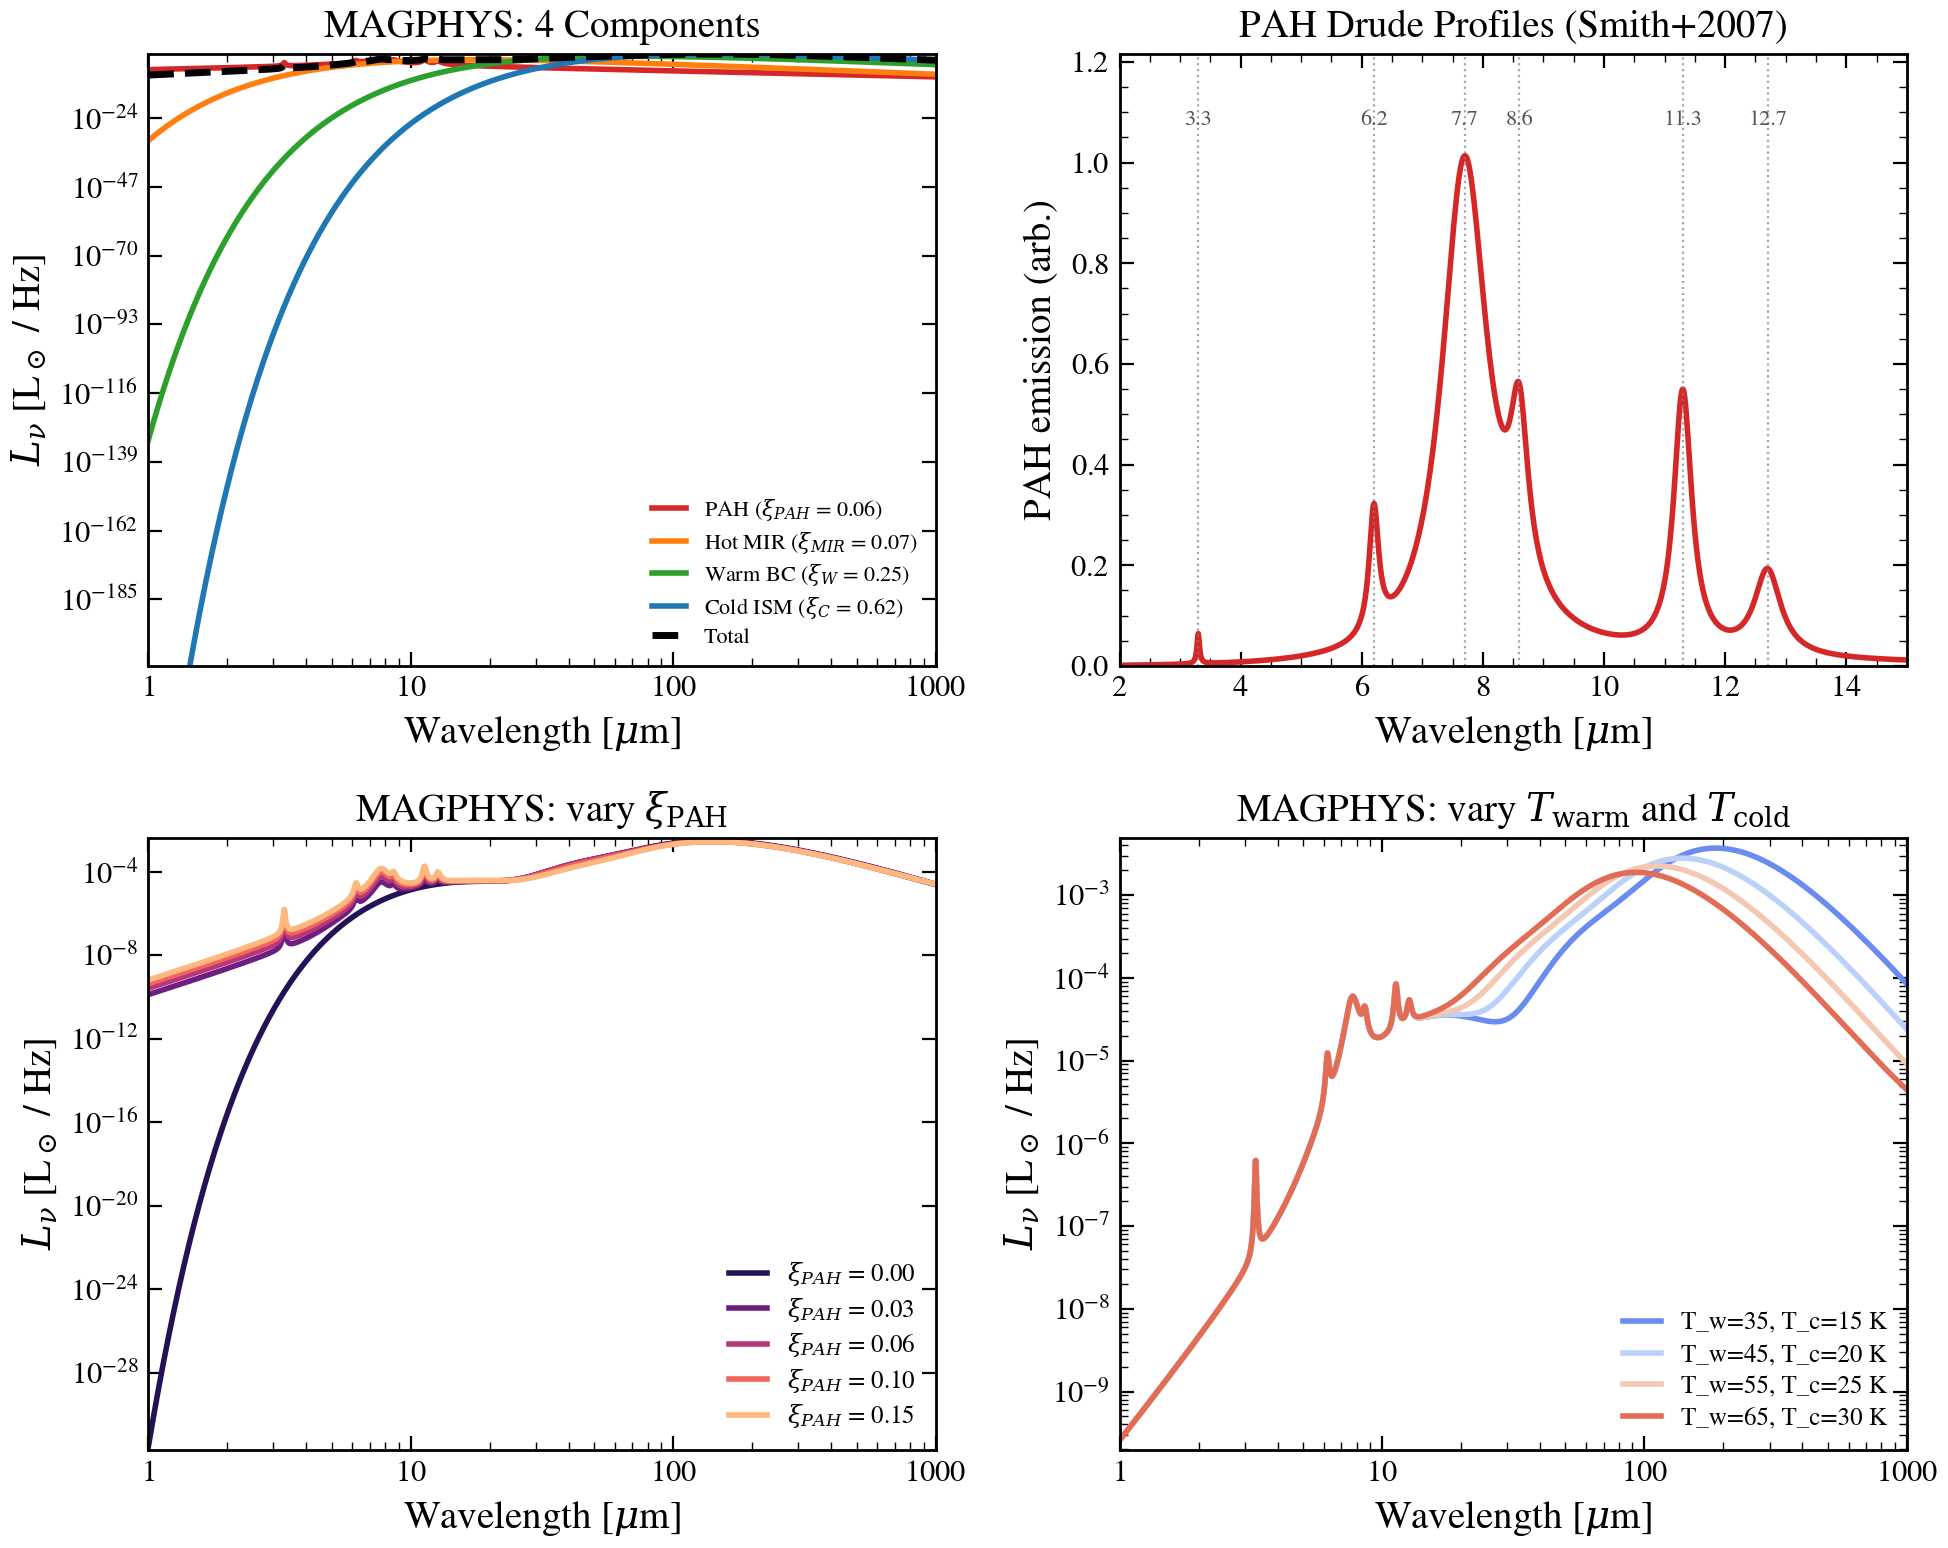

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- Panel 1: All 4 components ---
ax = axes[0, 0]

# Compute each component separately using the magphys decomposition
wavelength_cm = wave_aa * 1e-8
nu = 2.99792458e10 / wavelength_cm

# PAH component
pah_shape = _pah_template(wave_aa)
pah_integral = -jnp.trapezoid(pah_shape, nu)
pah_norm = jnp.where(pah_integral > 0.0, 1.0 / pah_integral, 0.0)
pah_component = pah_shape * pah_norm

# MBB components
hot_component = _modified_blackbody_component(wave_aa, 180.0, 1.5, 0.0)
warm_component = _modified_blackbody_component(wave_aa, 45.0, 1.5, 0.0)
cold_component = _modified_blackbody_component(wave_aa, 20.0, 2.0, 0.0)

xi_pah, xi_mir, xi_warm = 0.06, 0.07, 0.25
xi_cold = 1.0 - xi_pah - xi_mir - xi_warm

ax.plot(
    wave_um,
    np.array(L_ABS * xi_pah * pah_component),
    lw=2.0,
    color="#d62728",
    label=f"PAH ($\\xi_{{PAH}}$ = {xi_pah})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_mir * hot_component),
    lw=2.0,
    color="#ff7f0e",
    label=f"Hot MIR ($\\xi_{{MIR}}$ = {xi_mir})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_warm * warm_component),
    lw=2.0,
    color="#2ca02c",
    label=f"Warm BC ($\\xi_W$ = {xi_warm})",
)
ax.plot(
    wave_um,
    np.array(L_ABS * xi_cold * cold_component),
    lw=2.0,
    color="#1f77b4",
    label=f"Cold ISM ($\\xi_C$ = {xi_cold:.2f})",
)

# Total
lnu_total = magphys_dc08(
    wave_aa,
    L_ABS,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
    dust_T_hot=180.0,
    dust_xi_pah=xi_pah,
    dust_xi_mir=xi_mir,
    dust_xi_warm=xi_warm,
)
ax.plot(wave_um, np.array(lnu_total), lw=2.5, color="k", ls="--", label="Total", zorder=5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("MAGPHYS: 4 Components")
ax.set_xlim(1, 1000)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: PAH Drude profiles (zoom on 3--15 um) ---
ax = axes[0, 1]

# Fine wavelength grid for PAH features
wave_pah_aa = jnp.linspace(2e4, 15e4, 1000)  # 2--15 um
wave_pah_um = wave_pah_aa * 1e-4

pah_emission = _pah_template(wave_pah_aa)
ax.plot(wave_pah_um, np.array(pah_emission), lw=2.0, color="#d62728")

# Annotate each feature
pah_labels = ["3.3", "6.2", "7.7", "8.6", "11.3", "12.7"]
for j, lbl in enumerate(pah_labels):
    center = float(_PAH_CENTER_UM[j])
    ax.axvline(center, color="grey", ls=":", lw=0.8, alpha=0.7)
    ax.text(
        center,
        np.max(np.array(pah_emission)) * 1.05,
        f"{lbl}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#555555",
    )

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel("PAH emission (arb.)")
ax.set_title(r"PAH Drude Profiles (Smith+2007)")
ax.set_xlim(2, 15)
_emax = float(np.max(np.array(pah_emission)))
ax.set_ylim(0, _emax * 1.2)

# --- Panel 3: Vary xi_pah ---
ax = axes[1, 0]
xi_pah_values = [0.0, 0.03, 0.06, 0.10, 0.15]
cmap = plt.cm.magma
for i, xp in enumerate(xi_pah_values):
    color = cmap(0.15 + 0.7 * i / (len(xi_pah_values) - 1))
    # Adjust xi_warm to keep sum <= 1
    xw = max(0.0, 0.25 - max(0, xp - 0.06))
    lnu = magphys_dc08(wave_aa, L_ABS, dust_xi_pah=xp, dust_xi_mir=0.07, dust_xi_warm=xw)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\xi_{{PAH}}$ = {xp:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"MAGPHYS: vary $\xi_{\mathrm{PAH}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 4: Vary T_warm and T_cold ---
ax = axes[1, 1]
temp_pairs = [
    (35, 15, "T_w=35, T_c=15 K"),
    (45, 20, "T_w=45, T_c=20 K"),
    (55, 25, "T_w=55, T_c=25 K"),
    (65, 30, "T_w=65, T_c=30 K"),
]
cmap = plt.cm.coolwarm
for i, (tw, tc, lbl) in enumerate(temp_pairs):
    color = cmap(0.15 + 0.7 * i / (len(temp_pairs) - 1))
    lnu = magphys_dc08(wave_aa, L_ABS, dust_T_warm=float(tw), dust_T_cold=float(tc))
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=lbl)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"MAGPHYS: vary $T_{\mathrm{warm}}$ and $T_{\mathrm{cold}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_magphys_components.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Template-Based Models

Template-based models auto-load tabulated grids from `data/` on first
call. If templates are not found, they fall back to crude analytic
approximations (shown here with "(fallback)" labels). The fallbacks
are NOT suitable for science.

### 3a. Draine & Li 2007

Three parameters: `qPAH` (PAH mass fraction), `Umin` (minimum
radiation field intensity), `gamma` (fraction in PDR component).

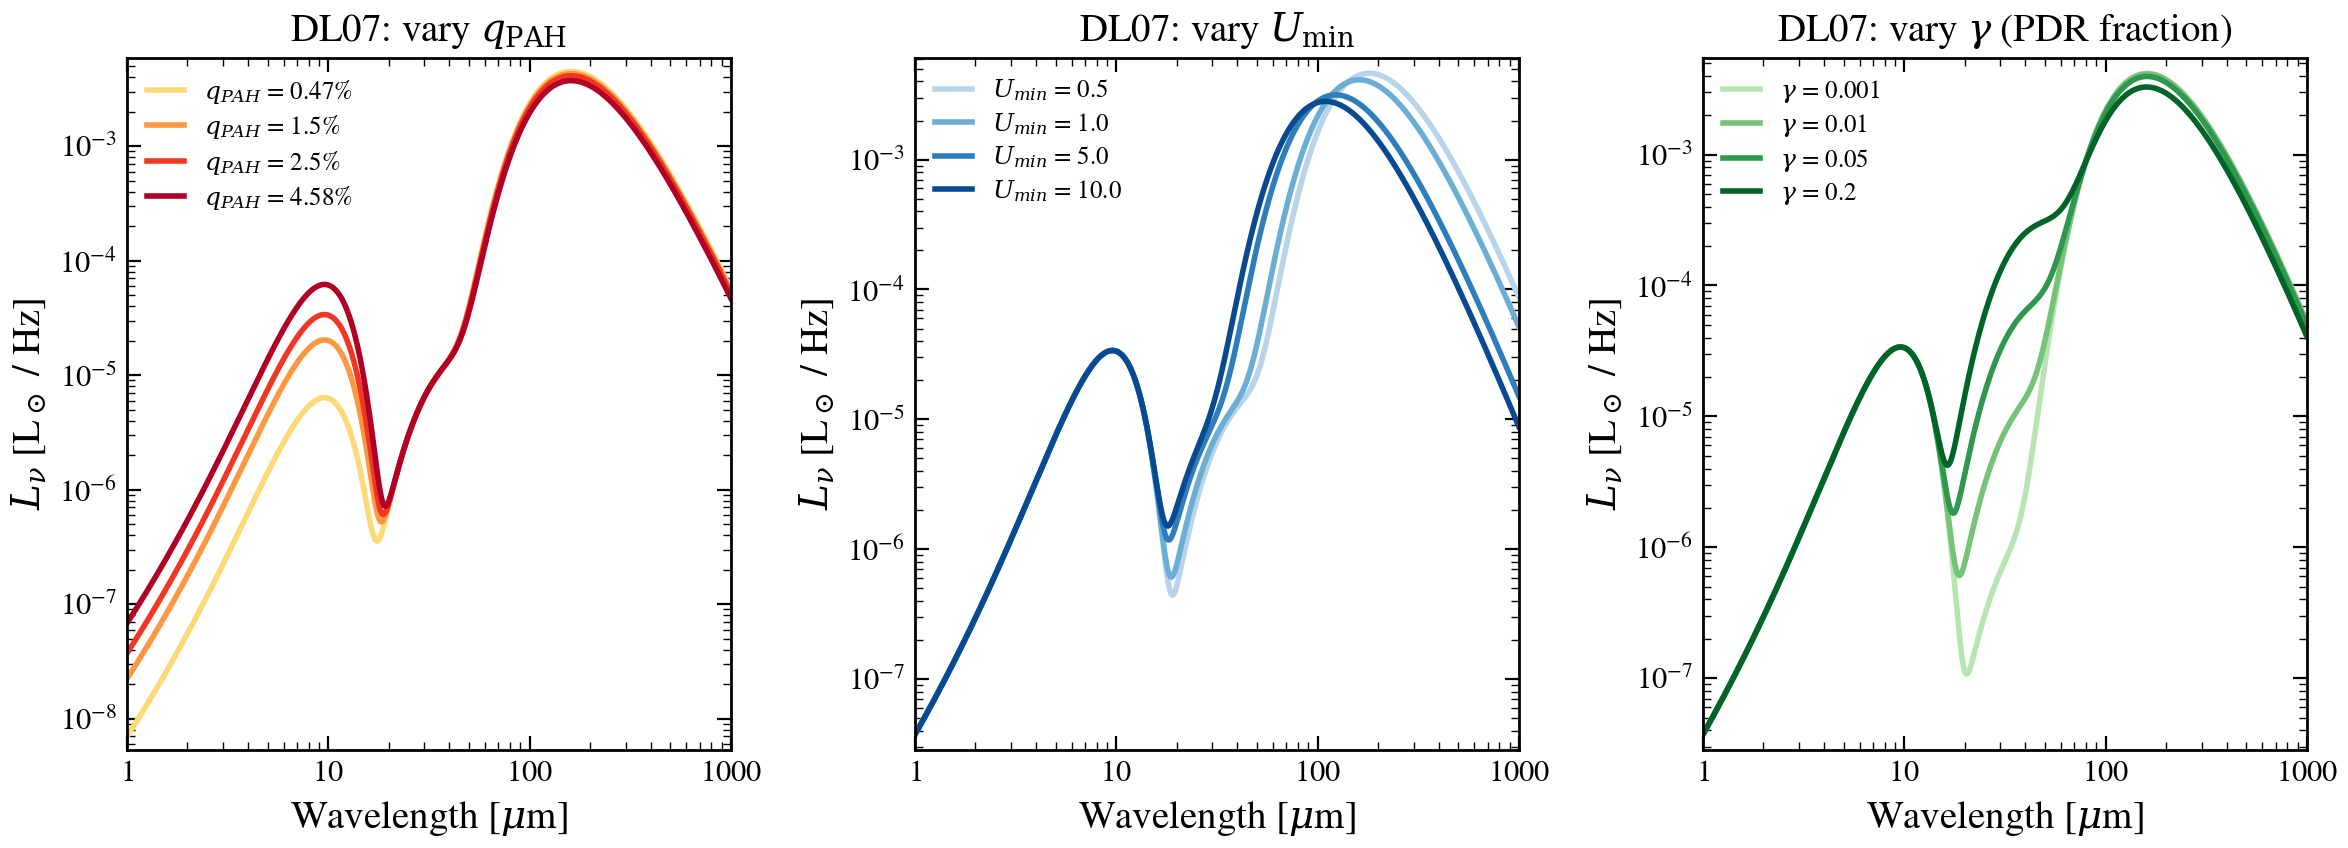

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

# --- Panel 1: Vary qPAH ---
ax = axes[0]
qpah_values = [0.47, 1.5, 2.5, 4.58]
cmap = plt.cm.YlOrRd
for i, qp in enumerate(qpah_values):
    color = cmap(0.25 + 0.65 * i / (len(qpah_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=qp
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$q_{{PAH}}$ = {qp}%")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $q_{\mathrm{PAH}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary Umin ---
ax = axes[1]
umin_values = [0.5, 1.0, 5.0, 10.0]
cmap = plt.cm.Blues
for i, um in enumerate(umin_values):
    color = cmap(0.3 + 0.6 * i / (len(umin_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=um, dust_gamma_dl=0.01, dust_qpah=2.5
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$U_{{min}}$ = {um}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $U_{\mathrm{min}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 3: Vary gamma (single-U vs PDR mix) ---
ax = axes[2]
gamma_values = [0.001, 0.01, 0.05, 0.20]
cmap = plt.cm.Greens
for i, gam in enumerate(gamma_values):
    color = cmap(0.3 + 0.6 * i / (len(gamma_values) - 1))
    lnu = _draine_li2007_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=gam, dust_qpah=2.5
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\gamma$ = {gam}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"DL07: vary $\gamma$ (PDR fraction)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_draine_li2007.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3b. Draine & Li 2014

Extension of DL07 with a free `alpha` parameter controlling the
distribution of radiation field intensities in the PDR component.
DL07 uses a fixed alpha=2.0.

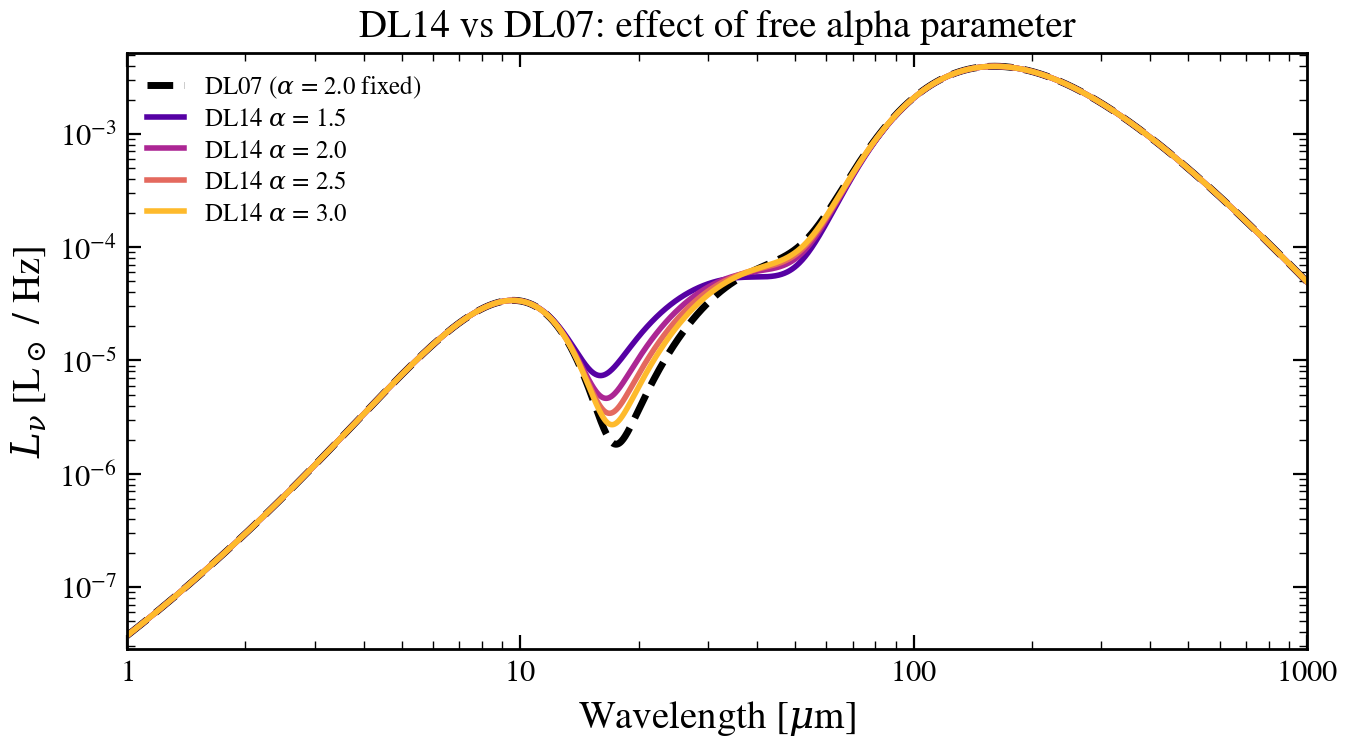

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

# DL07 reference
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.05, dust_qpah=2.5
)
ax.plot(
    wave_um, np.array(lnu_dl07), lw=2.5, color="k", ls="--", label=r"DL07 ($\alpha$ = 2.0 fixed)"
)

# DL14 with varying alpha
alpha_values = [1.5, 2.0, 2.5, 3.0]
cmap = plt.cm.plasma
for i, alpha in enumerate(alpha_values):
    color = cmap(0.15 + 0.7 * i / (len(alpha_values) - 1))
    lnu = _draine_li2014_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.05, dust_qpah=2.5, dust_alpha_dl14=alpha
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"DL14 $\alpha$ = {alpha:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("DL14 vs DL07: effect of free alpha parameter")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_draine_li2014.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3c. Dale+2014

One-parameter family of IR templates parameterized by alpha, which
controls the power-law distribution of dust heating intensities.
Low alpha = intense radiation field (warmer). High alpha = weak
radiation field (cooler).

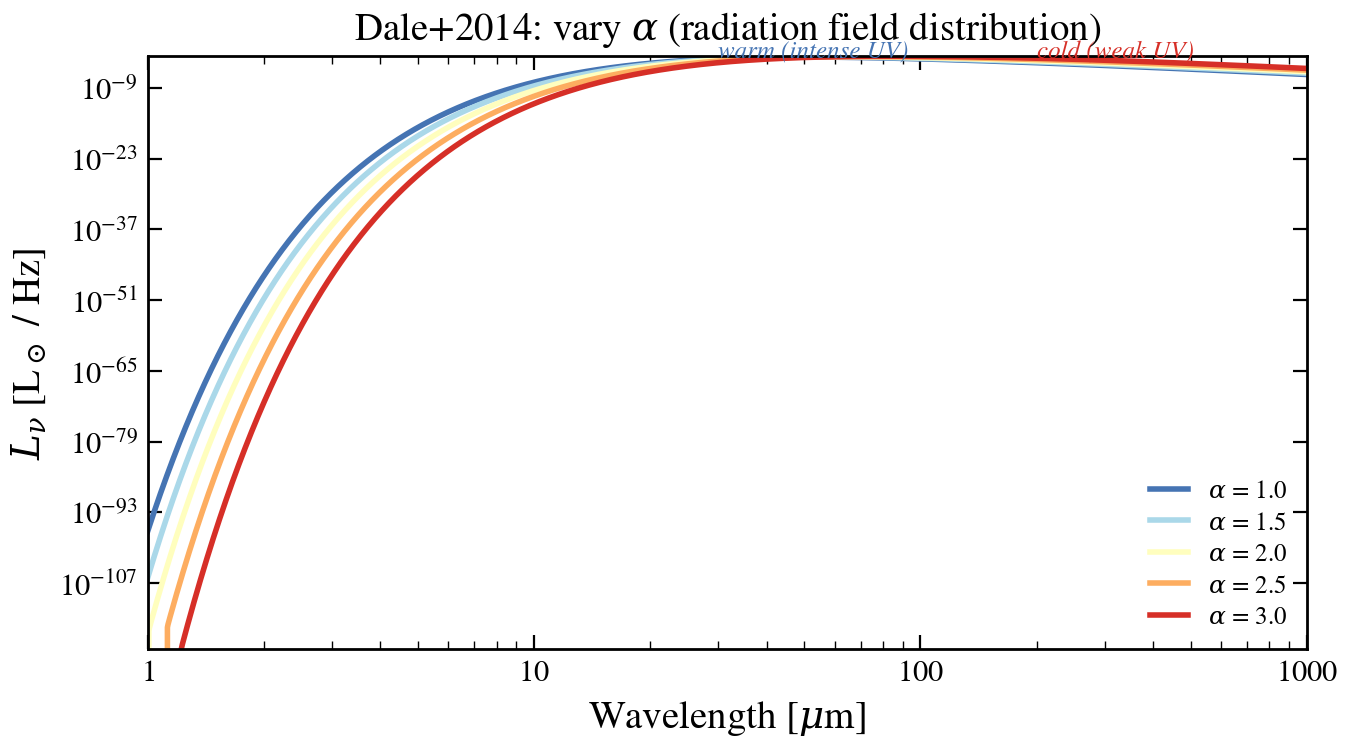

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

alpha_dale_values = [1.0, 1.5, 2.0, 2.5, 3.0]
cmap = plt.cm.RdYlBu_r
for i, alpha in enumerate(alpha_dale_values):
    color = cmap(0.1 + 0.8 * i / (len(alpha_dale_values) - 1))
    lnu = _dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=alpha)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=rf"$\alpha$ = {alpha:.1f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Dale+2014: vary $\alpha$ (radiation field distribution)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])

# Annotate warm/cold trend
ax.annotate(
    "warm (intense UV)",
    xy=(
        30,
        np.max(np.array(_dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=1.0))) * 0.8,
    ),
    fontsize=9,
    color=cmap(0.1),
    style="italic",
)
ax.annotate(
    "cold (weak UV)",
    xy=(
        200,
        np.max(np.array(_dale2014_analytic_fallback(wave_aa, L_ABS, dust_alpha_dale=3.0))) * 0.5,
    ),
    fontsize=9,
    color=cmap(0.9),
    style="italic",
)
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_dale2014.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3d. Astrodust+PAH (Hensley & Draine 2023)

Updated grain model from the Draine group. Uses observationally-derived
grain opacities (the "astrodust" model) rather than a mix of silicate
and graphite grains. Same mixing formula as DL07 but with different
underlying grain physics.

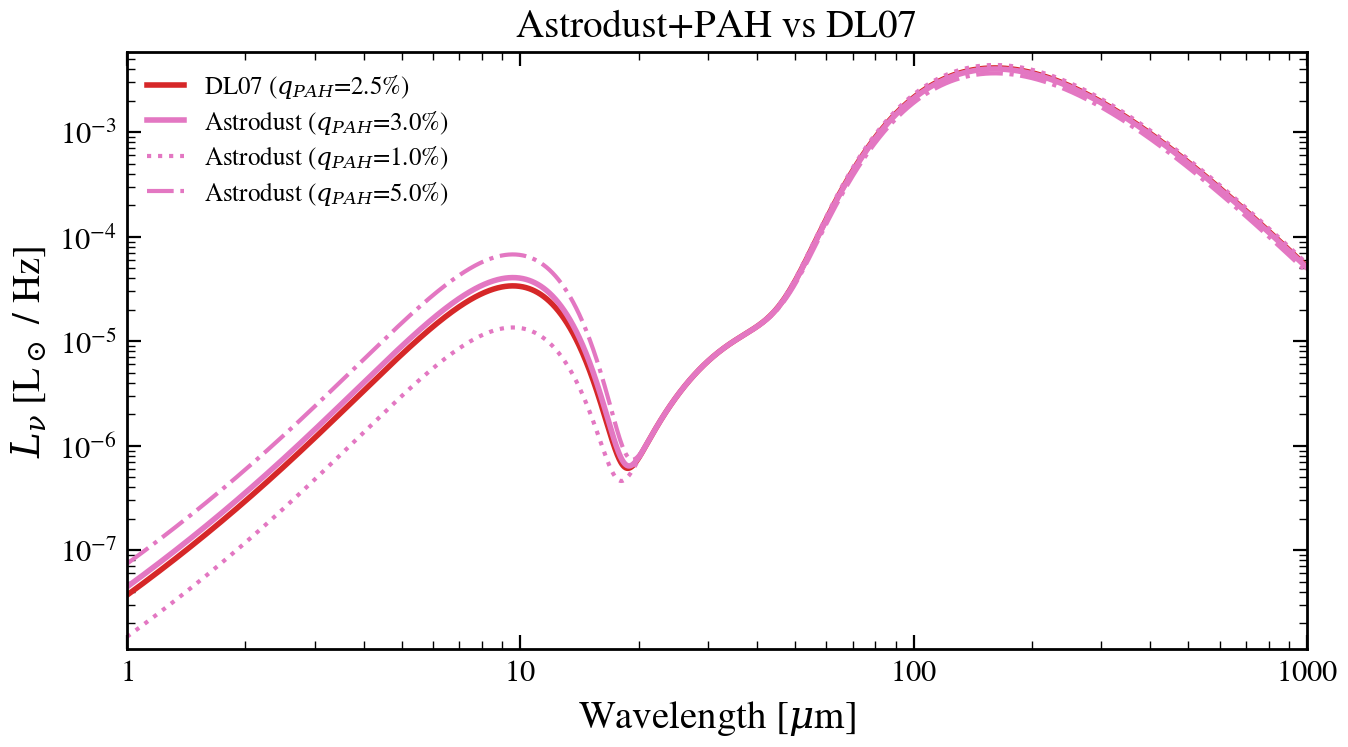

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

# Compare DL07 and Astrodust at same parameters
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
lnu_astro = _astrodust_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=3.0
)

ax.plot(
    wave_um,
    np.array(lnu_dl07),
    lw=2.0,
    color=MODEL_COLORS["draine_li2007"],
    label="DL07 ($q_{PAH}$=2.5%)",
)
ax.plot(
    wave_um,
    np.array(lnu_astro),
    lw=2.0,
    color=MODEL_COLORS["astrodust"],
    label="Astrodust ($q_{PAH}$=3.0%)",
)

# Show qPAH variation for Astrodust
for qp, ls in [(1.0, ":"), (5.0, "-.")]:
    lnu = _astrodust_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=qp
    )
    ax.plot(
        wave_um,
        np.array(lnu),
        lw=1.5,
        ls=ls,
        color=MODEL_COLORS["astrodust"],
        label=f"Astrodust ($q_{{PAH}}$={qp}%)",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Astrodust+PAH vs DL07")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_astrodust.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3e. BOSA (Boquien & Salim 2021)

Parameterized by (L_TIR, sSFR) rather than radiation field parameters.
High sSFR galaxies have warmer dust. This provides a direct
connection between star formation activity and dust temperature.

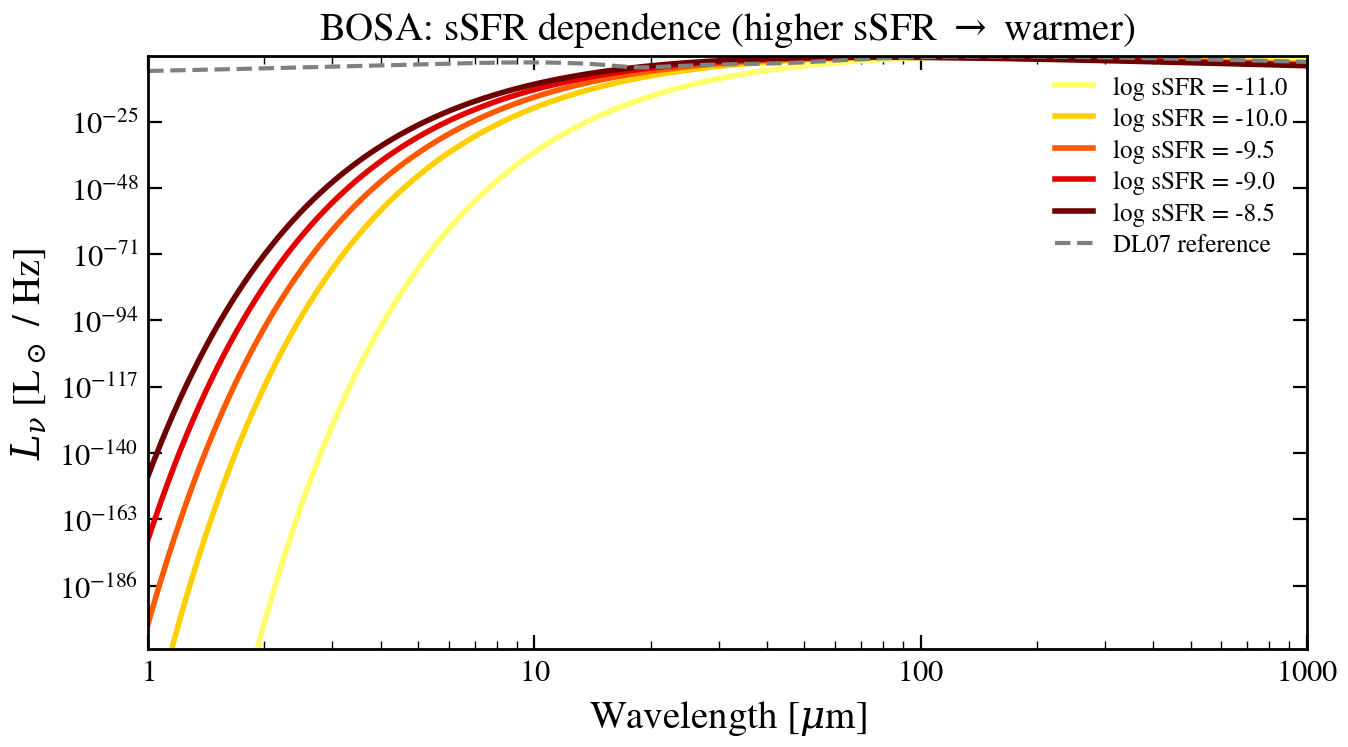

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

ssfr_values = [-11.0, -10.0, -9.5, -9.0, -8.5]
cmap = plt.cm.hot_r
for i, ssfr in enumerate(ssfr_values):
    color = cmap(0.15 + 0.7 * i / (len(ssfr_values) - 1))
    lnu = _bosa_analytic_fallback(wave_aa, L_ABS, dust_log_ssfr=ssfr)
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"log sSFR = {ssfr:.1f}")

# Reference DL07
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
ax.plot(wave_um, np.array(lnu_dl07), lw=1.5, ls="--", color="grey", label="DL07 reference")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"BOSA: sSFR dependence (higher sSFR $\rightarrow$ warmer)")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_bosa.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3f. THEMIS (Jones et al. 2017)

Based on the THEMIS/DustEM grain model. Uses `qhac` (a-C(:H) aromatic
carbon mass fraction) instead of `qPAH`. Different grain compositions
lead to different aromatic feature profiles and FIR/submm slopes.

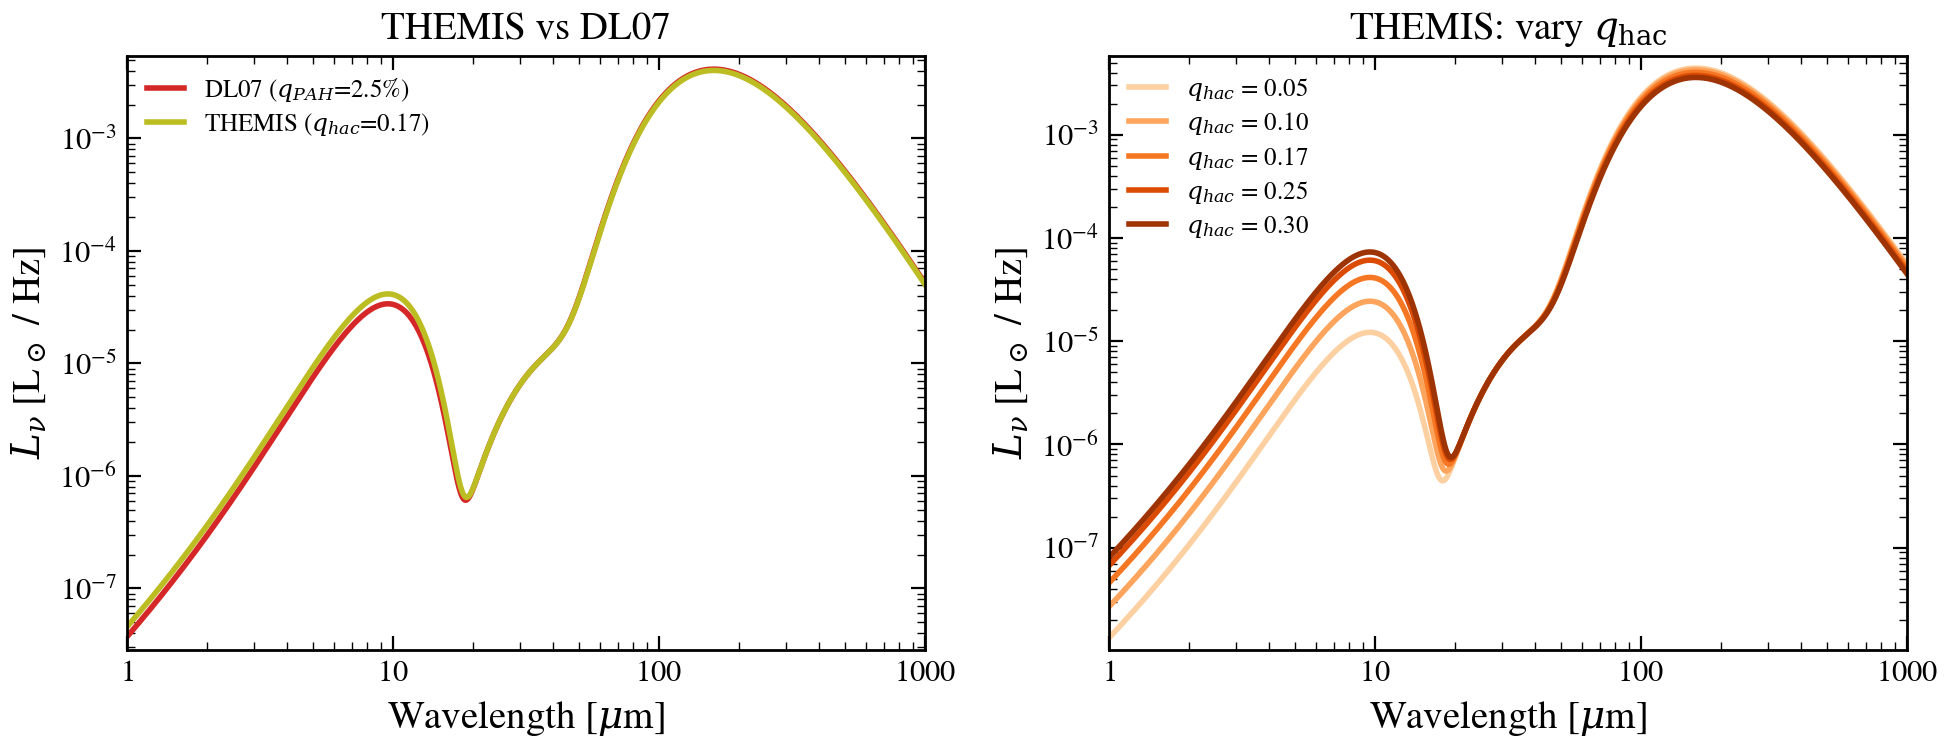

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: THEMIS vs DL07 ---
ax = axes[0]
lnu_dl07 = _draine_li2007_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qpah=2.5
)
lnu_themis = _themis_analytic_fallback(
    wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=0.17
)

ax.plot(
    wave_um,
    np.array(lnu_dl07),
    lw=2.0,
    color=MODEL_COLORS["draine_li2007"],
    label="DL07 ($q_{PAH}$=2.5%)",
)
ax.plot(
    wave_um,
    np.array(lnu_themis),
    lw=2.0,
    color=MODEL_COLORS["themis"],
    label="THEMIS ($q_{hac}$=0.17)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("THEMIS vs DL07")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary qhac ---
ax = axes[1]
qhac_values = [0.05, 0.10, 0.17, 0.25, 0.30]
cmap = plt.cm.Oranges
for i, qh in enumerate(qhac_values):
    color = cmap(0.25 + 0.65 * i / (len(qhac_values) - 1))
    lnu = _themis_analytic_fallback(
        wave_aa, L_ABS, dust_umin=1.0, dust_gamma_dl=0.01, dust_qhac=qh
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"$q_{{hac}}$ = {qh:.2f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"THEMIS: vary $q_{\mathrm{hac}}$")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_themis.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Energy Balance

The `energy_balance_split` model decomposes IR emission into warm
and cold components, with `eta_balance` controlling whether total
re-emission exactly equals absorbed luminosity (eta=1) or deviates
from strict energy balance (eta != 1).

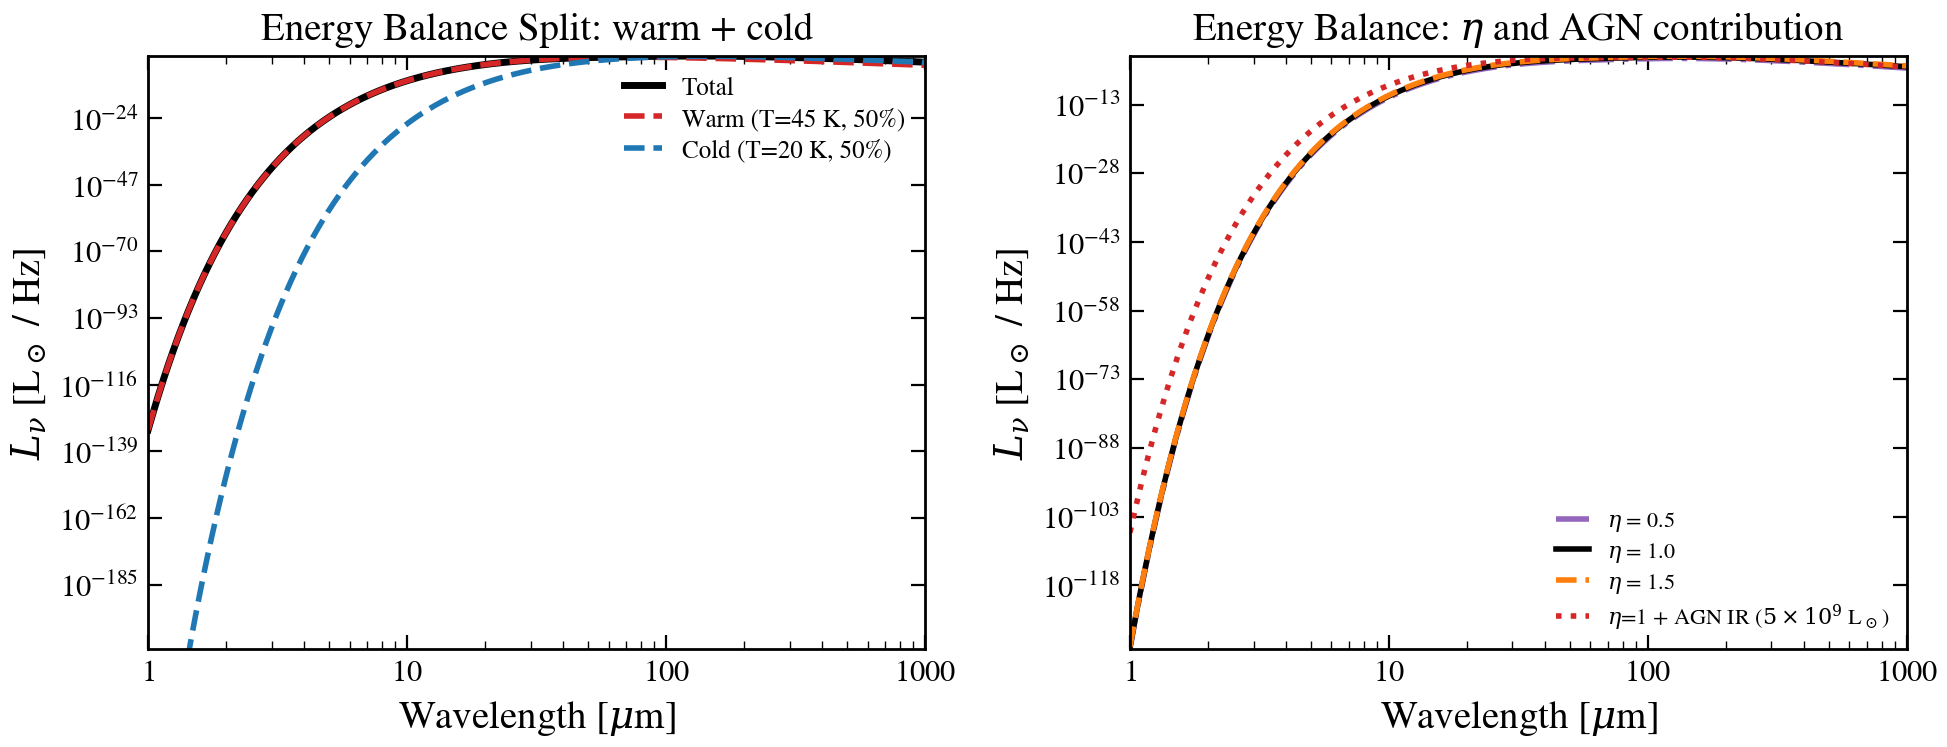

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: Warm + cold decomposition ---
ax = axes[0]

L_abs_stellar = 1e10
f_cold = 0.5
eta = 1.0
L_agn = 0.0

# Full model
lnu_full = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=f_cold,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Warm component only (f_cold=0)
lnu_warm = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=0.0,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Cold component only (f_cold=1)
lnu_cold = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=L_agn,
    eta_balance=eta,
    f_cold=1.0,
    dust_T_warm=45.0,
    dust_T_cold=20.0,
)

# Scale warm/cold to their actual fractions
ax.plot(wave_um, np.array(lnu_full), lw=2.5, color="k", label="Total")
ax.plot(
    wave_um, np.array(0.5 * lnu_warm), lw=2.0, ls="--", color="#d62728", label="Warm (T=45 K, 50%)"
)
ax.plot(
    wave_um, np.array(0.5 * lnu_cold), lw=2.0, ls="--", color="#1f77b4", label="Cold (T=20 K, 50%)"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title("Energy Balance Split: warm + cold")
ax.set_xlim(1, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

# --- Panel 2: Vary eta_balance and AGN contribution ---
ax = axes[1]

# Vary eta
eta_values = [0.5, 1.0, 1.5]
for eta_val, ls, clr in zip(eta_values, ["-.", "-", "--"], ["#9467bd", "k", "#ff7f0e"]):
    lnu = energy_balance_split(
        wave_aa,
        L_abs_stellar,
        L_agn_ir=0.0,
        eta_balance=eta_val,
        f_cold=0.5,
        dust_T_warm=45.0,
        dust_T_cold=20.0,
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, ls=ls, color=clr, label=rf"$\eta$ = {eta_val:.1f}")

# With AGN contribution
lnu_agn = energy_balance_split(
    wave_aa,
    L_abs_stellar,
    L_agn_ir=5e9,  # 50% extra from AGN
    eta_balance=1.0,
    f_cold=0.3,
    dust_T_warm=55.0,
    dust_T_cold=20.0,
)
ax.plot(
    wave_um,
    np.array(lnu_agn),
    lw=2.0,
    ls=":",
    color="#d62728",
    label=r"$\eta$=1 + AGN IR ($5\times10^9$ L$_\odot$)",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"Energy Balance: $\eta$ and AGN contribution")
ax.set_xlim(1, 1000)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_energy_balance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. CMB Corrections

At high redshift, the CMB sets a temperature floor on dust grains
and suppresses the observed Rayleigh-Jeans tail (da Cunha+2013).
The effective dust temperature becomes:

$$T_{\mathrm{eff}} = \left(T_{\mathrm{dust}}^{4+\beta} + T_{\mathrm{CMB}}(z)^{4+\beta} - T_{\mathrm{CMB}}(0)^{4+\beta}\right)^{1/(4+\beta)}$$

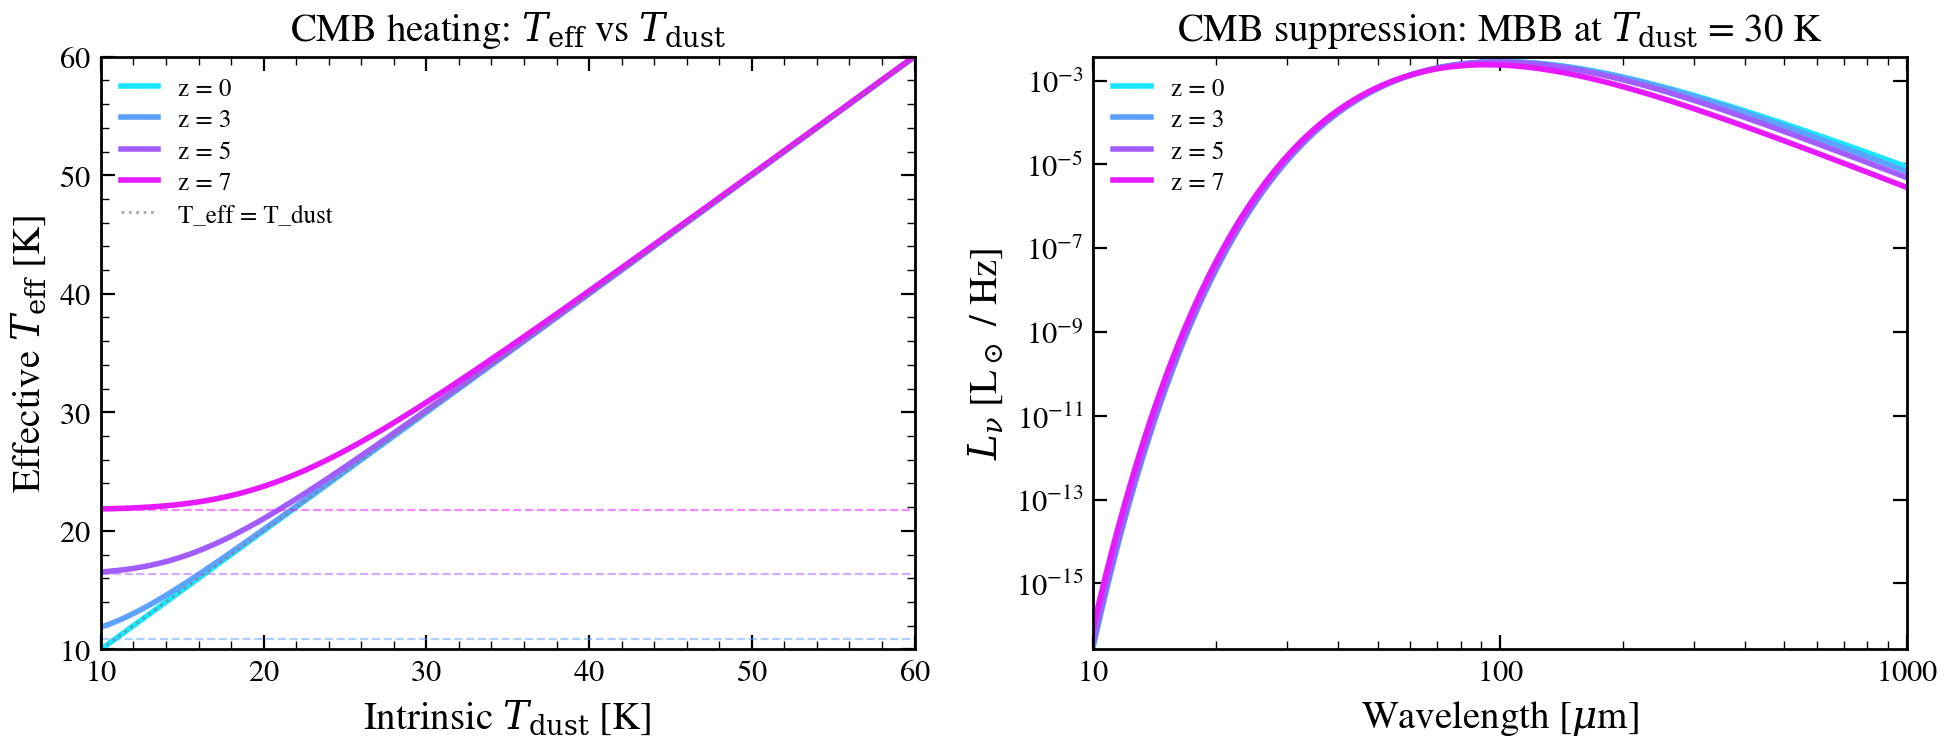

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Panel 1: T_eff vs T_dust at various redshifts ---
ax = axes[0]
T_dust_arr = np.linspace(10, 60, 100)
redshifts = [0, 3, 5, 7]
cmap = plt.cm.cool
for i, z in enumerate(redshifts):
    T_eff_arr = np.array(
        [float(cmb_corrected_temperature(float(T), float(z))) for T in T_dust_arr]
    )
    color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
    ax.plot(T_dust_arr, T_eff_arr, lw=2.0, color=color, label=f"z = {z}")

ax.plot([10, 60], [10, 60], ls=":", color="grey", lw=1.0, alpha=0.7, label="T_eff = T_dust")

# Mark T_CMB(z) floor
for i, z in enumerate(redshifts):
    T_cmb = 2.725 * (1 + z)
    if T_cmb < 60:
        color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
        ax.axhline(T_cmb, color=color, ls="--", lw=0.8, alpha=0.5)

ax.set_xlabel(r"Intrinsic $T_{\mathrm{dust}}$ [K]")
ax.set_ylabel(r"Effective $T_{\mathrm{eff}}$ [K]")
ax.set_title(r"CMB heating: $T_{\mathrm{eff}}$ vs $T_{\mathrm{dust}}$")
ax.legend(fontsize=9)
ax.set_xlim(10, 60)
ax.set_ylim(10, 60)

# --- Panel 2: Effect on FIR SED ---
ax = axes[1]
T_dust_ref = 30.0

for i, z in enumerate(redshifts):
    color = cmap(0.1 + 0.8 * i / (len(redshifts) - 1))
    lnu = modified_blackbody(
        wave_aa, L_ABS, dust_T=T_dust_ref, dust_beta_ir=1.8, redshift=float(z)
    )
    ax.plot(wave_um, np.array(lnu), lw=2.0, color=color, label=f"z = {z}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$L_\nu$ [L$_\odot$ / Hz]")
ax.set_title(r"CMB suppression: MBB at $T_{\mathrm{dust}}$ = 30 K")
ax.set_xlim(10, 1000)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([10, 100, 1000])
_set_reasonable_log_ylim(ax)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_cmb_corrections.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Summary Table

All 10 dust emission models in tengri.

In [16]:
summary_data = [
    ["modified_blackbody", "Analytic", "dust_T, dust_beta_ir", "None", "Hildebrand (1983)"],
    [
        "casey2012",
        "Analytic",
        "dust_T, dust_beta_ir, dust_alpha_mir",
        "None (MIR power law)",
        "Casey (2012)",
    ],
    [
        "magphys",
        "Analytic",
        "T_warm, T_cold, T_hot, xi_pah, xi_mir, xi_warm",
        "Drude profiles (Smith+07)",
        "da Cunha+2008",
    ],
    [
        "draine_li2007",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah",
        "Full treatment (silicate+graphite)",
        "Draine & Li (2007)",
    ],
    [
        "draine_li2014",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah, dust_alpha_dl14",
        "Full treatment (updated)",
        "Draine & Li (2014)",
    ],
    ["dale2014", "Tabulated", "dust_alpha_dale", "Embedded in templates", "Dale+2014"],
    [
        "astrodust",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qpah",
        "Astrodust+PAH grains",
        "Hensley & Draine (2023)",
    ],
    ["bosa", "Tabulated", "dust_log_ssfr", "Embedded in templates", "Boquien & Salim (2021)"],
    [
        "themis",
        "Tabulated",
        "dust_umin, dust_gamma_dl, dust_qhac",
        "a-C(:H) aromatics (DustEM)",
        "Jones+2017",
    ],
    [
        "energy_balance_split",
        "Analytic",
        "eta_balance, f_cold, T_warm, T_cold, L_agn_ir",
        "None (two MBBs)",
        "Kokorev+2021",
    ],
]

headers = ["Model", "Type", "Parameters", "PAH Treatment", "Reference"]

# Print table
print(
    f"{'Model':<22s} {'Type':<11s} {'Parameters':<50s} {'PAH Treatment':<30s} {'Reference':<25s}"
)
print("-" * 138)
for row in summary_data:
    print(f"{row[0]:<22s} {row[1]:<11s} {row[2]:<50s} {row[3]:<30s} {row[4]:<25s}")

Model                  Type        Parameters                                         PAH Treatment                  Reference                
------------------------------------------------------------------------------------------------------------------------------------------
modified_blackbody     Analytic    dust_T, dust_beta_ir                               None                           Hildebrand (1983)        
casey2012              Analytic    dust_T, dust_beta_ir, dust_alpha_mir               None (MIR power law)           Casey (2012)             
magphys                Analytic    T_warm, T_cold, T_hot, xi_pah, xi_mir, xi_warm     Drude profiles (Smith+07)      da Cunha+2008            
draine_li2007          Tabulated   dust_umin, dust_gamma_dl, dust_qpah                Full treatment (silicate+graphite) Draine & Li (2007)       
draine_li2014          Tabulated   dust_umin, dust_gamma_dl, dust_qpah, dust_alpha_dl14 Full treatment (updated)       Draine & Li (2014)     

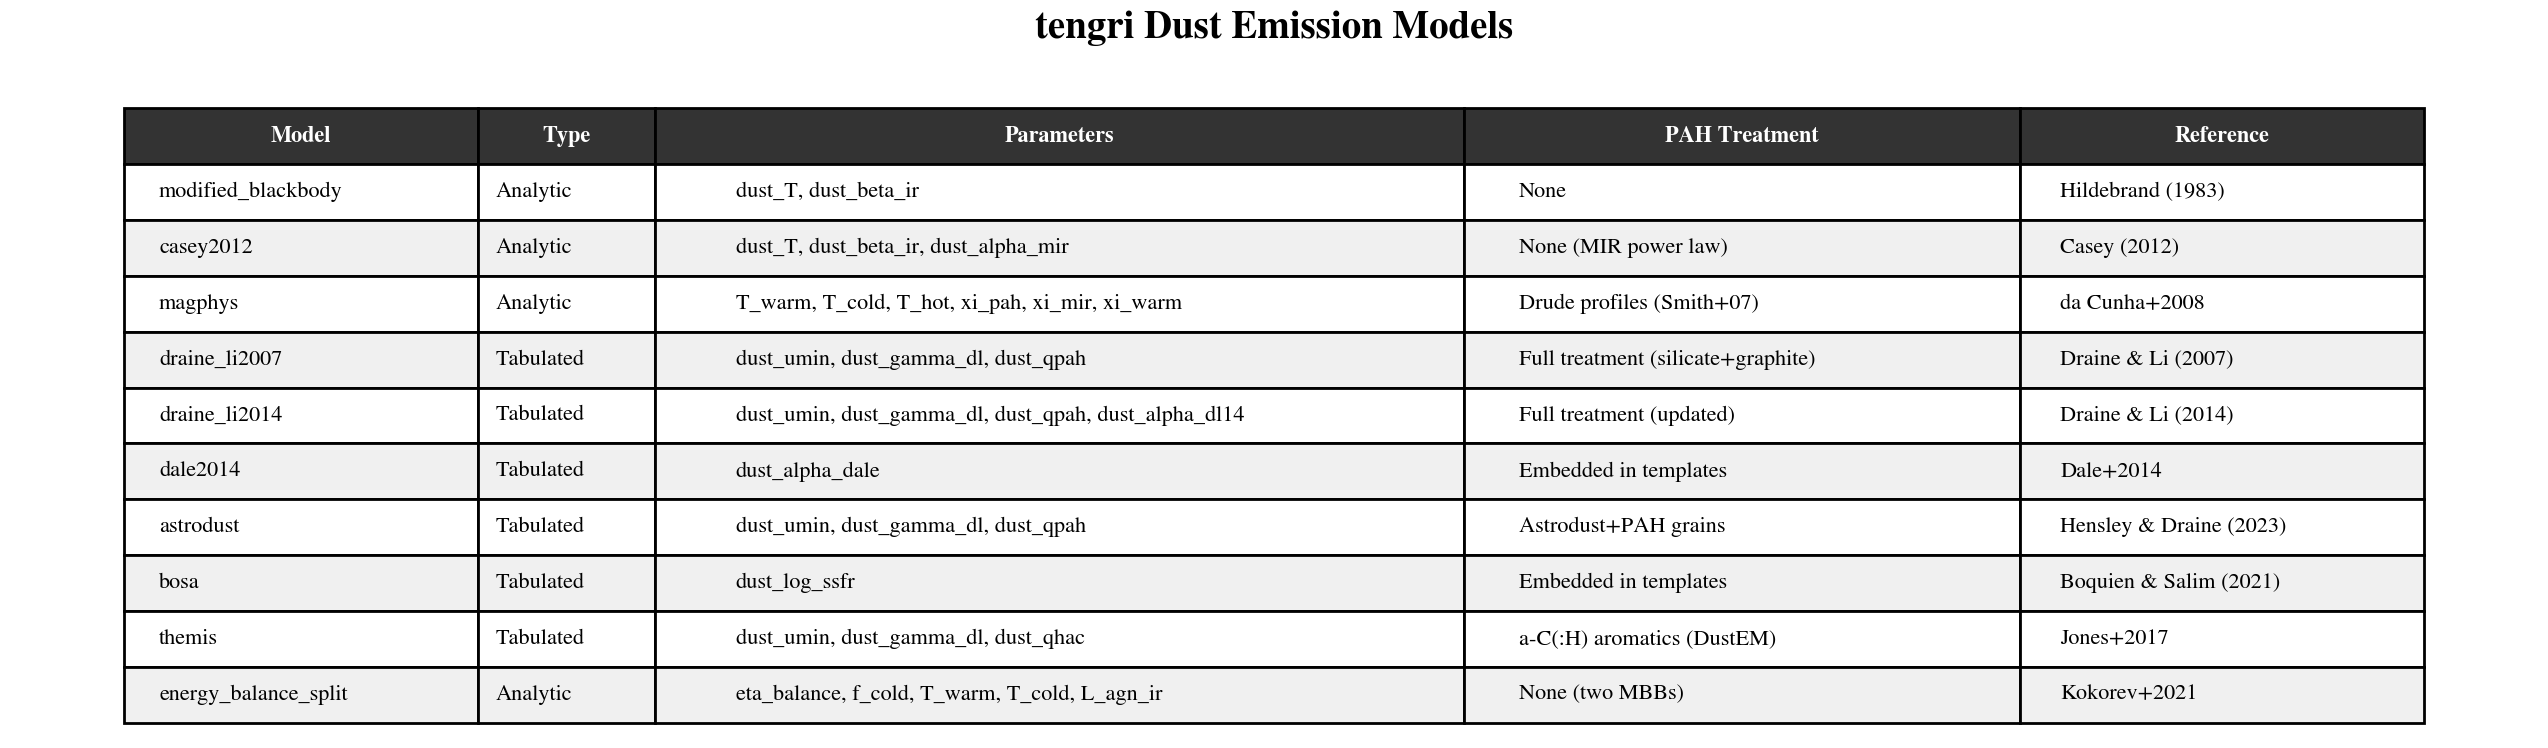

In [17]:
# Also display as a formatted figure table
fig, ax = plt.subplots(figsize=(13, 4.0))
ax.axis("off")

table = ax.table(
    cellText=summary_data,
    colLabels=headers,
    cellLoc="left",
    loc="center",
    colWidths=[0.14, 0.07, 0.32, 0.22, 0.16],
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.6)

# Style header row
for j in range(len(headers)):
    cell = table[0, j]
    cell.set_facecolor("#333333")
    cell.set_text_props(color="white", fontweight="bold")

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    bg = "#f0f0f0" if i % 2 == 0 else "white"
    for j in range(len(headers)):
        table[i, j].set_facecolor(bg)

ax.set_title("tengri Dust Emission Models", fontsize=14, fontweight="bold", pad=20)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "16_summary_table.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Notes

- Template-based models (DL07, DL14, Dale+2014, Astrodust, BOSA, THEMIS)
  auto-load tabulated grids from `data/` on first call. If templates
  are not found, crude analytic fallbacks are used with a warning.
  The fallbacks shown in this notebook are **not suitable for science**.

- All models enforce energy balance: the frequency integral of the
  emission SED equals `L_absorbed` (the total luminosity absorbed by
  dust in the UV/optical attenuation step).

- CMB corrections (da Cunha+2013) are applied automatically when
  `redshift > 0`. This affects the effective dust temperature and
  suppresses the Rayleigh-Jeans tail.

- The `energy_balance_split` model extends simple energy balance
  with warm/cold decomposition and optional AGN IR contribution.
  The `eta_balance` parameter allows departures from strict energy
  balance (spatial offsets between UV and FIR emission regions).